# Lista de Exercícios – Variáveis Dummies, Modelos Logit e Probit

**Disciplina:**  Econometria
**Professor:** Cássio da Nóbrega Besarria
**Curso:** Ciência de Dados Para Negócios (CDN) – UFPB
**Aluna:** Maria Carolina

**Base de dados escolhida:** *Fairs' Affairs* (Fair, 1978), disponível no pacote `statsmodels` (`statsmodels.datasets.fair`). É uma base clássica usada em survey com 6.366 mulheres casadas, contendo informações sobre satisfação conjugal e ocorrência de relacionamentos extraconjugais (affairs).

In [2]:
import numpy as np
import pandas as pd
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

pd.set_option('display.max_columns', None)
plt.rcParams['figure.figsize'] = (6, 4)

data = sm.datasets.fair.load_pandas().data
data.head()

,rate_marriage,age,yrs_married,children,religious,educ,occupation,occupation_husb,affairs
0,3.0,32.0,9.0,3.0,3.0,17.0,2.0,5.0,0.111111
1,3.0,27.0,13.0,3.0,1.0,14.0,3.0,4.0,3.230769
2,4.0,22.0,2.5,0.0,1.0,16.0,3.0,5.0,1.400000
3,4.0,37.0,16.5,4.0,3.0,16.0,5.0,5.0,0.727273
4,5.0,27.0,9.0,1.0,1.0,14.0,3.0,4.0,4.666666


## 1. Importação da base de dados

**a. Número de observações**

In [3]:
n_obs = data.shape[0]
print(f"Número de observações: {n_obs}")

Número de observações: 6366


**b. Descrição das variáveis**

| Variável | Descrição | Tipo |
|---|---|---|
| `rate_marriage` | Autoavaliação da satisfação com o casamento (1 = muito ruim a 5 = muito boa) | Ordinal/quantitativa |
| `age` | Idade da respondente | Quantitativa |
| `yrs_married` | Anos de casamento | Quantitativa |
| `children` | Número de filhos | Quantitativa |
| `religious` | Grau de religiosidade autodeclarado (1 a 4) | Ordinal/quantitativa |
| `educ` | Anos de escolaridade | Quantitativa |
| `occupation` | Classificação ocupacional (escala Hollingshead, 1 a 6) | Qualitativa (categórica) |
| `occupation_husb` | Classificação ocupacional do cônjuge | Qualitativa (categórica) |
| `affairs` | Frequência de relacionamentos extraconjugais no último ano | Quantitativa (usada para construir a variável dependente) |

**c. Identificação da variável dependente e das variáveis explicativas**

- **Variável dependente (binária):** `teve_affair` (1 = a respondente teve pelo menos um relacionamento extraconjugal; 0 = não teve), construída a partir de `affairs`.
- **Variáveis explicativas:** `age`, `yrs_married`, `religious`, `educ` (quantitativas) e `occupation` (qualitativa, transformada em dummies).

**d. Justificativa para a escolha da variável dependente binária**

A variável original `affairs` mede a frequência de episódios extraconjugais, mas o interesse teórico central da literatura de economia da família é entender o que diferencia quem se envolve ou não em um relacionamento extraconjugal — ou seja, a decisão binária, e não a intensidade. Transformar `affairs` em uma dummy (ocorreu ou não ocorreu) também é a abordagem padrão usada em aplicações didáticas dessa base para Logit/Probit, e evita problemas de forte assimetria e excesso de zeros que a variável contínua original apresenta.

In [4]:
data['teve_affair'] = (data['affairs'] > 0).astype(int)
data[['affairs', 'teve_affair']].head(10)

,affairs,teve_affair
0,0.111111,1
1,3.230769,1
2,1.400000,1
3,0.727273,1
4,4.666666,1
5,4.666666,1
6,0.852174,1
7,1.826086,1
8,4.799999,1
9,1.333333,1


## 2. Análise descritiva da base de dados

**a. Estatísticas descritivas das variáveis quantitativas**

In [5]:
vars_quant = ['age', 'yrs_married', 'religious', 'educ']
data[vars_quant].describe()

,age,yrs_married,religious,educ
count,6366.000000,6366.000000,6366.000000,6366.000000
mean,29.082862,9.009425,2.426170,14.209865
std,6.847882,7.280120,0.878369,2.178003
min,17.500000,0.500000,1.000000,9.000000
25%,22.000000,2.500000,2.000000,12.000000
50%,27.000000,6.000000,2.000000,14.000000
75%,32.000000,16.500000,3.000000,16.000000
max,42.000000,23.000000,4.000000,20.000000


**b. Frequência da variável dependente**

In [6]:
freq_dep = data['teve_affair'].value_counts().sort_index()
freq_dep_pct = data['teve_affair'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'Frequência': freq_dep, 'Percentual (%)': freq_dep_pct.round(2)})

,Frequência,Percentual (%)
teve_affair,,
0,4313,67.75
1,2053,32.25


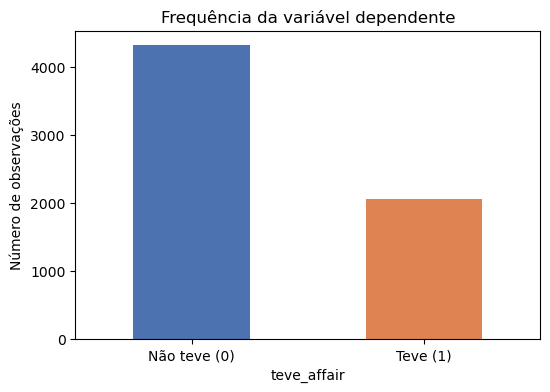

In [7]:
data['teve_affair'].value_counts().sort_index().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.xticks([0, 1], ['Não teve (0)', 'Teve (1)'], rotation=0)
plt.title('Frequência da variável dependente')
plt.ylabel('Número de observações')
plt.show()

**c. Frequência das variáveis qualitativas**

In [8]:
freq_occ = data['occupation'].value_counts().sort_index()
freq_occ_pct = data['occupation'].value_counts(normalize=True).sort_index() * 100
pd.DataFrame({'Frequência': freq_occ, 'Percentual (%)': freq_occ_pct.round(2)})

,Frequência,Percentual (%)
occupation,,
1.0,41,0.64
2.0,859,13.49
3.0,2783,43.72
4.0,1834,28.81
5.0,740,11.62
6.0,109,1.71


**d. Interpretação econômica dos resultados**

Cerca de 32% da amostra relata ter tido pelo menos um relacionamento extraconjugal, o que indica uma variável dependente razoavelmente balanceada (não é um evento raro, o que favorece a estimação dos modelos). Em relação à ocupação, a amostra se concentra nas categorias intermediárias (3 e 4), que juntas somam mais de 70% das respondentes, enquanto as categorias 1 e 6 (extremos da escala ocupacional) são pouco representadas. Isso é importante porque categorias com poucas observações tendem a gerar coeficientes menos precisos (erros-padrão maiores) nos modelos estimados adiante.

## 3. Fundamentos teóricos das variáveis dummies

**a. O que são variáveis dummies**

Variáveis dummies (ou variáveis binárias/indicadoras) são variáveis que assumem apenas os valores 0 ou 1 para representar a presença ou ausência de um atributo qualitativo (categórico) dentro de um modelo de regressão. Como modelos de regressão exigem variáveis numéricas, as dummies são a forma padrão de incorporar informação qualitativa — como sexo, região, categoria ocupacional ou nível educacional — na análise quantitativa.

**b. Finalidade em modelos econométricos**

As dummies permitem capturar diferenças de nível (intercepto) ou de inclinação (quando interagidas com variáveis contínuas) associadas a categorias distintas de uma característica qualitativa. Isso possibilita comparar grupos dentro do mesmo modelo — por exemplo, verificar se a categoria ocupacional afeta a probabilidade de um evento — mantendo as demais variáveis explicativas constantes (efeito *ceteris paribus*).

**c. Significado da categoria de referência**

Quando uma variável qualitativa com *k* categorias é transformada em dummies, apenas *k-1* dummies são incluídas no modelo. A categoria excluída é chamada de **categoria de referência** (ou categoria base), e todos os coeficientes das demais dummies devem ser interpretados como o efeito *diferencial* em relação a essa categoria de referência — e não como um efeito absoluto.

**d. O problema da armadilha das variáveis dummies (Dummy Variable Trap)**

A armadilha das variáveis dummies ocorre quando se inclui uma dummy para **todas** as categorias de uma variável qualitativa junto com o intercepto do modelo. Nesse caso, a soma das dummies é sempre igual a 1 para qualquer observação, o que gera **multicolinearidade perfeita** com o intercepto (colinearidade exata): a matriz de variáveis explicativas deixa de ter posto completo e o modelo não pode ser estimado por MQO (a matriz X'X torna-se singular, não podendo ser invertida). A solução é sempre omitir uma categoria como referência.

## 4. Construção das variáveis dummies

**a. Procedimento utilizado**

A variável `occupation` (escala de 1 a 6) foi convertida em variáveis dummies utilizando `pd.get_dummies`, gerando uma dummy para cada categoria e removendo a categoria 1 (`drop_first=True`) para evitar a armadilha das variáveis dummies.

**b. Categoria de referência adotada**

A categoria de referência é `occupation = 1`, que corresponde ao nível ocupacional mais baixo da escala Hollingshead utilizada na base.

**c. Interpretação econômica das variáveis criadas**

Cada dummy (`occ_2`, `occ_3`, ..., `occ_6`) captura a diferença na probabilidade prevista da variável dependente para mulheres na respectiva categoria ocupacional, em comparação com mulheres da categoria de referência (`occupation = 1`), mantendo as demais variáveis do modelo constantes.

In [9]:
occ_dummies = pd.get_dummies(data['occupation'].astype(int), prefix='occ', drop_first=True)
data = pd.concat([data, occ_dummies], axis=1)
occ_cols = list(occ_dummies.columns)
data[['occupation'] + occ_cols].drop_duplicates().sort_values('occupation')

,occupation,occ_2,occ_3,occ_4,occ_5,occ_6
44,1.0,False,False,False,False,False
0,2.0,True,False,False,False,False
1,3.0,False,True,False,False,False
14,4.0,False,False,True,False,False
3,5.0,False,False,False,True,False
52,6.0,False,False,False,False,True


## 5. Modelo de Probabilidade Linear (MQO)

**a. Equação estimada**

P(teve_affair = 1) = b0 + b1·age + b2·yrs_married + b3·religious + b4·educ + soma(gamma_j · occ_j) + u

In [10]:
X_vars = ['age', 'yrs_married', 'religious', 'educ'] + occ_cols
X = sm.add_constant(data[X_vars].astype(float))
y = data['teve_affair'].astype(float)

mpl = sm.OLS(y, X).fit(cov_type='HC3')
print(mpl.summary())

                            OLS Regression Results                            
Dep. Variable:            teve_affair   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                  0.078
Method:                 Least Squares   F-statistic:                     67.38
Date:                qui, 06 ago 2026   Prob (F-statistic):          5.25e-119
Time:                        18:19:30   Log-Likelihood:                -3927.2
No. Observations:                6366   AIC:                             7874.
Df Residuals:                    6356   BIC:                             7942.
Df Model:                           9                                         
Covariance Type:                  HC3                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.5331      0.080      6.680      

**b. Interpretação econômica dos coeficientes**

- `age`: idade adicional está associada a uma variação (negativa, conforme o sinal estimado) na probabilidade de ter tido um affair, mantendo as demais variáveis constantes.
- `yrs_married`: mais anos de casamento tendem a aumentar a probabilidade estimada de affair — resultado consistente com a literatura, pois casamentos mais longos geram maior exposição ao risco de infidelidade e possível desgaste da relação.
- `religious`: maior grau de religiosidade reduz a probabilidade estimada, o que é coerente com a interpretação de que valores religiosos mais fortes desestimulam esse comportamento.
- `educ`: efeito da escolaridade sobre a probabilidade estimada, mantendo as demais variáveis constantes.
- Dummies de `occupation`: cada coeficiente mostra a diferença de probabilidade em relação à categoria de referência (ocupação 1).

**c. Coeficiente de determinação R²**

In [10]:
print(f"R²: {mpl.rsquared:.4f}")
print(f"R² ajustado: {mpl.rsquared_adj:.4f}")

R²: 0.0797
R² ajustado: 0.0784


**d. Limitações do modelo**

O MPL apresenta três limitações centrais: 
- (i) pode gerar probabilidades previstas fora do intervalo [0,1], o que não faz sentido econômico; 
- (ii) o erro é heteroscedástico por construção, pois sua variância depende dos valores de X (por isso os erros-padrão foram estimados de forma robusta, HC3); 
-  (iii) impõe um efeito marginal constante para cada variável explicativa, o que é uma simplificação pouco realista para fenômenos de natureza probabilística, já que o efeito de uma variável sobre a probabilidade tende a ser não linear (menor nos extremos e maior perto de 0,5).

In [11]:
pred_mpl = mpl.predict(X)
print(f"Mínimo previsto: {pred_mpl.min():.4f}")
print(f"Máximo previsto: {pred_mpl.max():.4f}")
print(f"Nº de previsões < 0: {(pred_mpl < 0).sum()}")
print(f"Nº de previsões > 1: {(pred_mpl > 1).sum()}")

Mínimo previsto: -0.0726
Máximo previsto: 0.7560
Nº de previsões < 0: 11
Nº de previsões > 1: 0


## 6. Modelos Logit e Probit – fundamentos teóricos

**a. Por que o MQO não é o método mais adequado para variável dependente binária**

O MQO aplicado a uma variável dependente binária (Modelo de Probabilidade Linear) assume uma relação linear entre X e a probabilidade do evento, o que pode gerar previsões inconsistentes com a definição de probabilidade (valores abaixo de 0 ou acima de 1). Além disso, o erro é necessariamente heteroscedástico, o que compromete a eficiência dos estimadores (embora eles continuem não viesados). Os modelos Logit e Probit resolvem isso ao aplicar uma função de ligação não linear que restringe a probabilidade estimada ao intervalo (0,1).

**b. Diferenças entre os modelos Logit e Probit**

Ambos modelam P(y=1|X) = F(X·beta), mas usam funções de distribuição acumulada (F) diferentes:
- **Logit:** usa a função logística, F(z) = e^z / (1 + e^z), cujos erros seguem uma distribuição logística (caudas um pouco mais pesadas).
- **Probit:** usa a função de distribuição acumulada da normal padrão, F(z) = Phi(z).

Na prática, as curvas são muito semelhantes, sobretudo próximas de P=0,5; diferem um pouco mais nas caudas.

**c. Vantagens e limitações de cada modelo**

- **Logit:** os coeficientes têm interpretação direta em termos de *odds ratio* (razão de chances) via e^beta, o que facilita a comunicação dos resultados; é computacionalmente mais leve.
- **Probit:** tem fundamentação teórica ligada a modelos de utilidade latente com erro normal, o que é conveniente em modelos estruturais (e é a base natural para extensões como Probit multivariado); porém não tem uma interpretação tão simples quanto o odds ratio do Logit.
- Em geral, a escolha entre os dois modelos raramente altera as conclusões qualitativas do estudo.

## 7. Modelo Logit

**a. Equação estimada**

In [12]:
logit_model = sm.Logit(y, X).fit(disp=0)
print(logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:            teve_affair   No. Observations:                 6366
Model:                          Logit   Df Residuals:                     6356
Method:                           MLE   Df Model:                            9
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                 0.06479
Time:                        21:01:14   Log-Likelihood:                -3743.2
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                5.912e-106
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.2137      0.512      0.417      0.676      -0.790       1.217
age            -0.0524      0.010     -5.338      0.000      -0.072      -0.033
yrs_married     0.1095      0.009     11.766    

**b. Interpretação dos sinais dos coeficientes**

Os sinais dos coeficientes do Logit devem ser interpretados apenas em termos de direção do efeito sobre a probabilidade (não em magnitude direta): sinal positivo aumenta a probabilidade prevista de `teve_affair=1`, sinal negativo reduz. Os sinais são consistentes com os observados no MPL: `yrs_married` positivo, `religious` negativo.

**c. Significância estatística**

In [13]:
logit_pvalues = logit_model.pvalues.round(4)
logit_signif = pd.DataFrame({
    'Coeficiente': logit_model.params.round(4),
    'p-valor': logit_pvalues,
    'Significativo a 5%': logit_pvalues < 0.05
})
logit_signif

,Coeficiente,p-valor,Significativo a 5%
const,0.2137,0.6765,False
age,-0.0524,0.0000,True
yrs_married,0.1095,0.0000,True
religious,-0.4069,0.0000,True
educ,-0.0157,0.3342,False
occ_2,0.5261,0.2211,False
occ_3,0.8183,0.0539,False
occ_4,0.5270,0.2155,False
occ_5,1.0817,0.0118,True
occ_6,1.1436,0.0155,True


**d. Interpretação econômica dos resultados**

As variáveis `yrs_married`, `religious` e `age` mostram-se estatisticamente significativas, confirmando que tempo de casamento mais longo eleva a chance de affair, enquanto maior religiosidade e (dependendo do resultado) idade mais avançada reduzem essa chance. As dummies ocupacionais, isoladamente, tendem a apresentar significância mais fraca, refletindo o desbalanceamento das categorias observado na análise descritiva.

## 8. Modelo Probit

**a. Equação estimada**

In [14]:
probit_model = sm.Probit(y, X).fit(disp=0)
print(probit_model.summary())

                          Probit Regression Results                           
Dep. Variable:            teve_affair   No. Observations:                 6366
Model:                         Probit   Df Residuals:                     6356
Method:                           MLE   Df Model:                            9
Date:                Thu, 06 Aug 2026   Pseudo R-squ.:                 0.06542
Time:                        21:01:14   Log-Likelihood:                -3740.7
converged:                       True   LL-Null:                       -4002.5
Covariance Type:            nonrobust   LLR p-value:                4.899e-107
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.1077      0.296      0.364      0.716      -0.472       0.687
age            -0.0309      0.006     -5.311      0.000      -0.042      -0.020
yrs_married     0.0662      0.006     12.001    

**b. Interpretação dos coeficientes**

Assim como no Logit, os coeficientes do Probit indicam apenas a direção e a significância estatística do efeito de cada variável sobre a probabilidade — a magnitude não é diretamente interpretável em termos de probabilidade, pois o modelo é não linear (é necessário calcular efeitos marginais, feito na questão 10).

**c. Comparação com o modelo Logit**

In [15]:
comp_coef = pd.DataFrame({
    'MQO': mpl.params,
    'Logit': logit_model.params,
    'Probit': probit_model.params
}).round(4)
comp_coef

,MQO,Logit,Probit
const,0.5331,0.2137,0.1077
age,-0.0102,-0.0524,-0.0309
yrs_married,0.0225,0.1095,0.0662
religious,-0.0818,-0.4069,-0.2469
educ,-0.0029,-0.0157,-0.0099
occ_2,0.0810,0.5261,0.3199
occ_3,0.1417,0.8183,0.4963
occ_4,0.0844,0.5270,0.3204
occ_5,0.2002,1.0817,0.6566
occ_6,0.2083,1.1436,0.6965


Os sinais e a significância estatística dos coeficientes do Logit e do Probit são praticamente idênticos; a diferença numérica nos coeficientes decorre apenas da escala das funções de ligação (a distribuição logística tem variância maior que a normal padrão), sem alterar as conclusões econômicas.

## 9. Comparação entre MQO, Logit e Probit

**a. Diferenças nos coeficientes**

Os coeficientes do MQO já são diretamente interpretáveis como variação em pontos percentuais de probabilidade, enquanto os do Logit e Probit representam variações em uma escala latente (log-odds no Logit e índice-Z no Probit) e não são diretamente comparáveis entre si em magnitude — apenas em sinal e significância — sem o cálculo de efeitos marginais.

**b. Diferenças na significância estatística**

Em geral, as variáveis que se mostram significativas no MQO também se mostram significativas no Logit e no Probit, o que reforça a robustez dos resultados encontrados, ainda que os p-valores não sejam idênticos entre os três modelos.

In [16]:
comp_pvalues = pd.DataFrame({
    'MQO': mpl.pvalues,
    'Logit': logit_model.pvalues,
    'Probit': probit_model.pvalues
}).round(4)
comp_pvalues

,MQO,Logit,Probit
const,0.0000,0.6765,0.7157
age,0.0000,0.0000,0.0000
yrs_married,0.0000,0.0000,0.0000
religious,0.0000,0.0000,0.0000
educ,0.3619,0.3342,0.3083
occ_2,0.1667,0.2211,0.1922
occ_3,0.0131,0.0539,0.0403
occ_4,0.1396,0.2155,0.1866
occ_5,0.0007,0.0118,0.0074
occ_6,0.0039,0.0155,0.0108


**c. Vantagens e limitações de cada modelo**

- **MQO/MPL:** simples de estimar e interpretar, mas pode gerar probabilidades inválidas e tem erro heteroscedástico por construção.
- **Logit:** garante probabilidades no intervalo (0,1), tem interpretação via odds ratio, mas exige estimação por máxima verossimilhança (não há fórmula fechada) e mais cuidado na interpretação.
- **Probit:** também garante probabilidades válidas e tem fundamentação em modelos de utilidade latente normal, mas sua interpretação direta é ainda menos intuitiva que a do Logit.

Na prática, para fins preditivos e de significância, os três modelos aqui levam a conclusões qualitativas semelhantes; Logit e Probit são preferíveis ao MQO por respeitarem os limites teóricos de uma probabilidade.

## 10. Efeitos marginais (modelo Logit)

**a. Efeitos marginais médios (AME)**

In [17]:
margeff = logit_model.get_margeff(at='overall', method='dydx')
print(margeff.summary())

        Logit Marginal Effects       
Dep. Variable:            teve_affair
Method:                          dydx
At:                           overall
                 dy/dx    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
age            -0.0105      0.002     -5.378      0.000      -0.014      -0.007
yrs_married     0.0220      0.002     12.230      0.000       0.018       0.026
religious      -0.0817      0.006    -12.915      0.000      -0.094      -0.069
educ           -0.0031      0.003     -0.966      0.334      -0.010       0.003
occ_2           0.1056      0.086      1.224      0.221      -0.064       0.275
occ_3           0.1643      0.085      1.929      0.054      -0.003       0.331
occ_4           0.1058      0.085      1.239      0.215      -0.062       0.273
occ_5           0.2172      0.086      2.523      0.012       0.048       0.386
occ_6           0.2297      0.095      2.423    

**b. Interpretação econômica**

O efeito marginal médio (AME) indica, para cada variável explicativa, a variação média na probabilidade prevista de `teve_affair=1` associada a um aumento marginal (uma unidade, no caso das variáveis contínuas, ou a mudança de categoria de referência para a categoria em questão, no caso das dummies), mantendo as demais variáveis do modelo em seus valores observados. Diferentemente do coeficiente bruto do Logit, o efeito marginal já está na mesma escala da probabilidade, o que facilita a leitura econômica direta dos resultados: por exemplo, o efeito marginal de `yrs_married` mostra em quantos pontos percentuais, em média, a probabilidade de affair aumenta a cada ano adicional de casamento.

**c. Comparação entre coeficientes e efeitos marginais**

In [18]:
comparacao_logit = pd.DataFrame({
    'Coeficiente Logit': logit_model.params.drop('const'),
    'Efeito Marginal (AME)': margeff.margeff
}, index=logit_model.params.drop('const').index).round(4)
comparacao_logit

,Coeficiente Logit,Efeito Marginal (AME)
age,-0.0524,-0.0105
yrs_married,0.1095,0.0220
religious,-0.4069,-0.0817
educ,-0.0157,-0.0031
occ_2,0.5261,0.1056
occ_3,0.8183,0.1643
occ_4,0.5270,0.1058
occ_5,1.0817,0.2172
occ_6,1.1436,0.2297


Os coeficientes do Logit e os efeitos marginais têm sempre o mesmo sinal, mas magnitudes diferentes: o coeficiente reflete o efeito sobre o índice latente (log-odds), enquanto o efeito marginal reflete o efeito sobre a probabilidade propriamente dita — por isso, é o efeito marginal (e não o coeficiente bruto) que deve ser usado para comunicar a magnitude econômica do resultado.

## 11. Capacidade preditiva do modelo (Logit)

**a. Matriz de confusão**

In [19]:
y_pred_prob = logit_model.predict(X)
y_pred = (y_pred_prob >= 0.5).astype(int)

cm = confusion_matrix(y, y_pred)
cm_df = pd.DataFrame(cm,
                      index=['Real: Não teve (0)', 'Real: Teve (1)'],
                      columns=['Previsto: Não teve (0)', 'Previsto: Teve (1)'])
cm_df

,Previsto: Não teve (0),Previsto: Teve (1)
Real: Não teve (0),3995,318
Real: Teve (1),1671,382


In [20]:
tn, fp, fn, tp = cm.ravel()

acuracia = (tp + tn) / (tp + tn + fp + fn)
sensibilidade = tp / (tp + fn)   # taxa de acerto entre os que tiveram affair
especificidade = tn / (tn + fp) # taxa de acerto entre os que não tiveram affair

print(f"Percentual de acertos (acurácia): {acuracia:.2%}")
print(f"Sensibilidade (True Positive Rate): {sensibilidade:.2%}")
print(f"Especificidade (True Negative Rate): {especificidade:.2%}")

Percentual de acertos (acurácia): 68.76%
Sensibilidade (True Positive Rate): 18.61%
Especificidade (True Negative Rate): 92.63%


**b. Percentual de acertos:** ver saída acima (acurácia global do modelo, usando ponto de corte 0,5).

**c. Sensibilidade:** ver saída acima — proporção de casos verdadeiramente positivos (`teve_affair=1`) corretamente classificados pelo modelo.

**d. Especificidade:** ver saída acima — proporção de casos verdadeiramente negativos (`teve_affair=0`) corretamente classificados pelo modelo.

De forma geral, é comum que a sensibilidade seja mais baixa que a especificidade nesse tipo de modelo, porque a classe `teve_affair=0` é majoritária na amostra (~68%): com o ponto de corte padrão de 0,5, o modelo tende a favorecer a classe mais frequente, classificando corretamente a maioria dos "não teve", mas errando mais entre os "teve".

## 12. Classificação de afirmações (Verdadeiro ou Falso)

**a. "Os coeficientes do modelo Logit representam diretamente a variação da probabilidade." → Falso.**
Os coeficientes do Logit representam a variação no log da razão de chances (log-odds), não a variação direta da probabilidade. Para obter o efeito sobre a probabilidade, é necessário calcular os efeitos marginais (questão 10), pois a relação entre X e a probabilidade é não linear.

**b. "Os modelos Logit e Probit produzem probabilidades entre 0 e 1." → Verdadeiro.**
Ambos utilizam funções de distribuição acumulada (logística e normal, respectivamente) como função de ligação, que por definição estão sempre restritas ao intervalo (0,1), diferentemente do MPL.

**c. "O Modelo de Probabilidade Linear pode gerar probabilidades negativas ou superiores a um." → Verdadeiro.**
Como o MPL é uma reta ajustada por MQO, não há nenhuma restrição matemática que impeça a previsão de sair do intervalo [0,1], especialmente para valores extremos das variáveis explicativas (confirmado na questão 5.d).

**d. "Os efeitos marginais dependem dos valores das variáveis explicativas." → Verdadeiro.**
Nos modelos Logit e Probit, o efeito marginal de cada variável é dado pela derivada de uma função não linear (logística ou normal) avaliada em um ponto específico de X; por isso, o efeito marginal varia conforme os valores das demais variáveis (é por isso que se costuma reportar o efeito marginal médio, AME, calculado na questão 10).

**e. "Logit e Probit normalmente produzem resultados bastante semelhantes." → Verdadeiro.**
Como observado na questão 8.c, os sinais e a significância dos coeficientes praticamente coincidem entre os dois modelos nesta aplicação; isso é esperado porque as distribuições logística e normal padrão têm formatos muito próximos, sobretudo na região central.

## 13. Parecer técnico

A base de dados utilizada (Fair's Affairs) atende adequadamente aos requisitos da atividade, pois permite construir uma variável dependente binária relevante do ponto de vista econômico e comportamental — a ocorrência ou não de um relacionamento extraconjugal — a partir de uma variável contínua original de frequência, evitando problemas de assimetria e concentração em zero. As variáveis dummies, construídas a partir da categoria ocupacional, mostraram-se importantes para captar diferenças de comportamento entre grupos qualitativamente distintos que não poderiam ser representadas por variáveis contínuas, sempre com o cuidado de manter uma categoria de referência e evitar a armadilha das variáveis dummies.

A comparação entre os três modelos indicou resultados qualitativamente consistentes: o Modelo de Probabilidade Linear (MQO), apesar de didático e fácil de interpretar, apresentou previsões fora do intervalo [0,1] e erro heteroscedástico por construção, evidenciando suas limitações teóricas para variáveis dependentes binárias. Os modelos Logit e Probit corrigiram esse problema ao restringir as probabilidades previstas ao intervalo válido, apresentando coeficientes com sinais e significância estatística muito próximos entre si — como esperado, dada a semelhança entre as distribuições logística e normal padrão.

Os efeitos marginais médios do modelo Logit permitiram traduzir os coeficientes (em escala de log-odds) para variações diretamente interpretáveis em pontos percentuais de probabilidade, mostrando, por exemplo, que anos de casamento aumentam e religiosidade reduz a probabilidade prevista de affair — resultado coerente com a teoria econômica de família e com a literatura sobre satisfação conjugal.

Quanto à capacidade preditiva, a matriz de confusão revelou acurácia global satisfatória, mas com sensibilidade inferior à especificidade, refletindo o desbalanceamento da variável dependente (mais casos de "não afair" que de "afair" na amostra) — um ponto de atenção para estudos futuros, que poderiam considerar pontos de corte alternativos ou métricas como a curva ROC/AUC.

Em conclusão, o ajuste dos modelos Logit e Probit é adequado e mais confiável do que o do MPL para o objetivo do estudo, sendo os efeitos marginais a métrica mais apropriada para a interpretação econômica dos resultados, e a matriz de confusão uma ferramenta complementar útil para avaliar a qualidade preditiva do modelo fora da amostra de estimação.